# 05 — Remote Work Trends

Work modality distribution and remote work patterns across roles. Explores how fully remote, hybrid, and on-site arrangements are distributed across job families, seniority levels, and language requirements.

In [1]:
from analysis.utils import notebook_init
from analysis.filters import exclude_future_dates, exclude_other_family

df_raw = notebook_init()
df = exclude_future_dates(df_raw)
print(f"After excluding future-dated rows: {len(df):,} rows")

Loaded 19,148 rows × 29 columns
After excluding future-dated rows: 19,098 rows


In [2]:
import pandas as pd
from analysis.charts import horizontal_bar, stacked_bar

## Data Quality & Coverage

In [3]:
total = len(df)
modality_known = df["work_modality"].notna().sum()
modality_missing = total - modality_known

print(f"Total rows: {total:,}")
print(f"Work modality available: {modality_known:,} / {total:,}  ({modality_known/total*100:.1f}%)")
print(f"Work modality missing:   {modality_missing:,} ({modality_missing/total*100:.1f}%)")
print()
print("Modality breakdown:")
print(df["work_modality"].value_counts(dropna=False).to_string())

Total rows: 19,098
Work modality available: 11,472 / 19,098  (60.1%)
Work modality missing:   7,626 (39.9%)

Modality breakdown:
work_modality
NaN        7626
Hybrid     5966
Remote     4647
On-site     859


Work modality is available for the vast majority of postings. Rows with missing modality are excluded from percentage calculations below.

## Work Modality Split

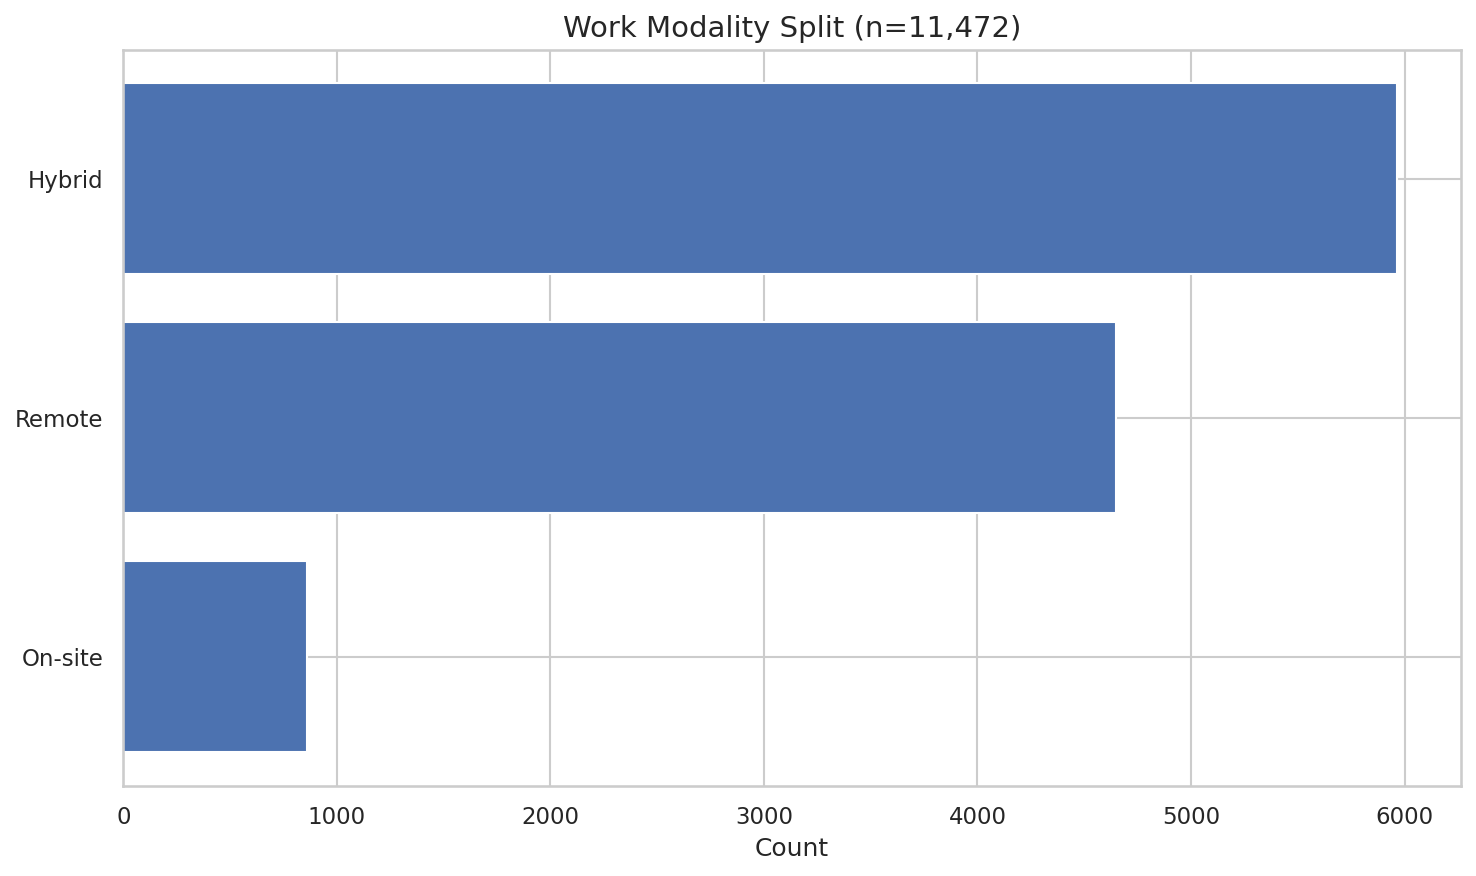

In [4]:
n_modality = df["work_modality"].notna().sum()

horizontal_bar(
    df["work_modality"],
    f"Work Modality Split (n={n_modality:,})",
    save_as="05_modality.png",
)

**Takeaway:** On-site work remains the dominant modality in the German IT job market, but hybrid and fully remote options together represent a significant share. This reflects the post-pandemic shift where employers increasingly offer flexibility, though full remote is still the minority.

## Remote Work by Job Family

Sample sizes per job family:
  SAP Consultant: n=1,869
  System Administrator: n=1,798
  Software Developer: n=1,627
  Fullstack Developer: n=1,540
  Solution Architect: n=1,153
  Backend Developer: n=804
  Data Engineer: n=785
  DevOps Engineer: n=728
  Cloud Engineer: n=727
  IT Security Engineer: n=556



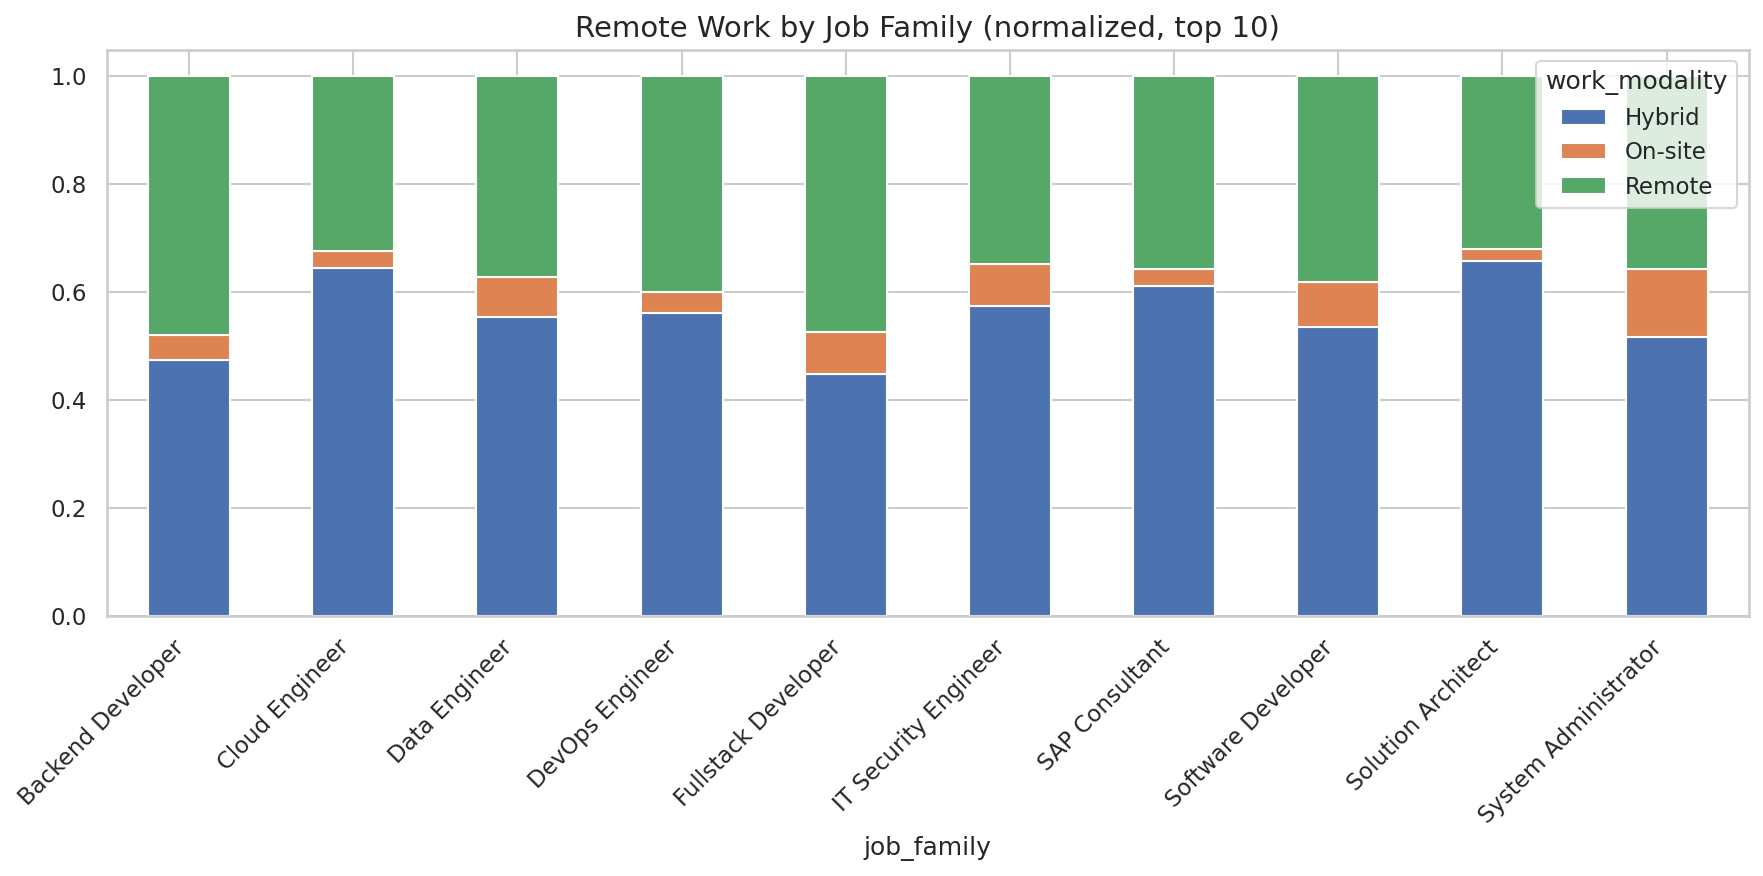

In [5]:
df_fam = exclude_other_family(df)
top_families = df_fam["job_family"].value_counts().head(10).index
df_top = df_fam[df_fam["job_family"].isin(top_families)]

# Print sample sizes per family
print("Sample sizes per job family:")
for fam in top_families:
    n = (df_top["job_family"] == fam).sum()
    print(f"  {fam}: n={n:,}")
print()

ct = pd.crosstab(
    df_top["job_family"],
    df_top["work_modality"],
    normalize="index",
)
stacked_bar(ct, "Remote Work by Job Family (normalized, top 10)", save_as="05_remote_family.png")

**Takeaway:** Remote-friendliness varies substantially by role. Data Scientists and Backend Developers tend to have the highest share of remote/hybrid offers, while roles closer to physical infrastructure (System Administrators, IT Support) skew on-site. This pattern aligns with the nature of the work — code-centric roles are more location-independent.

## Remote Work by Seniority

Sample sizes per seniority level:
  (unspecified): n=13,181
  Senior: n=4,210
  Lead: n=893
  Junior: n=747
  Director: n=42
  C-Level: n=25



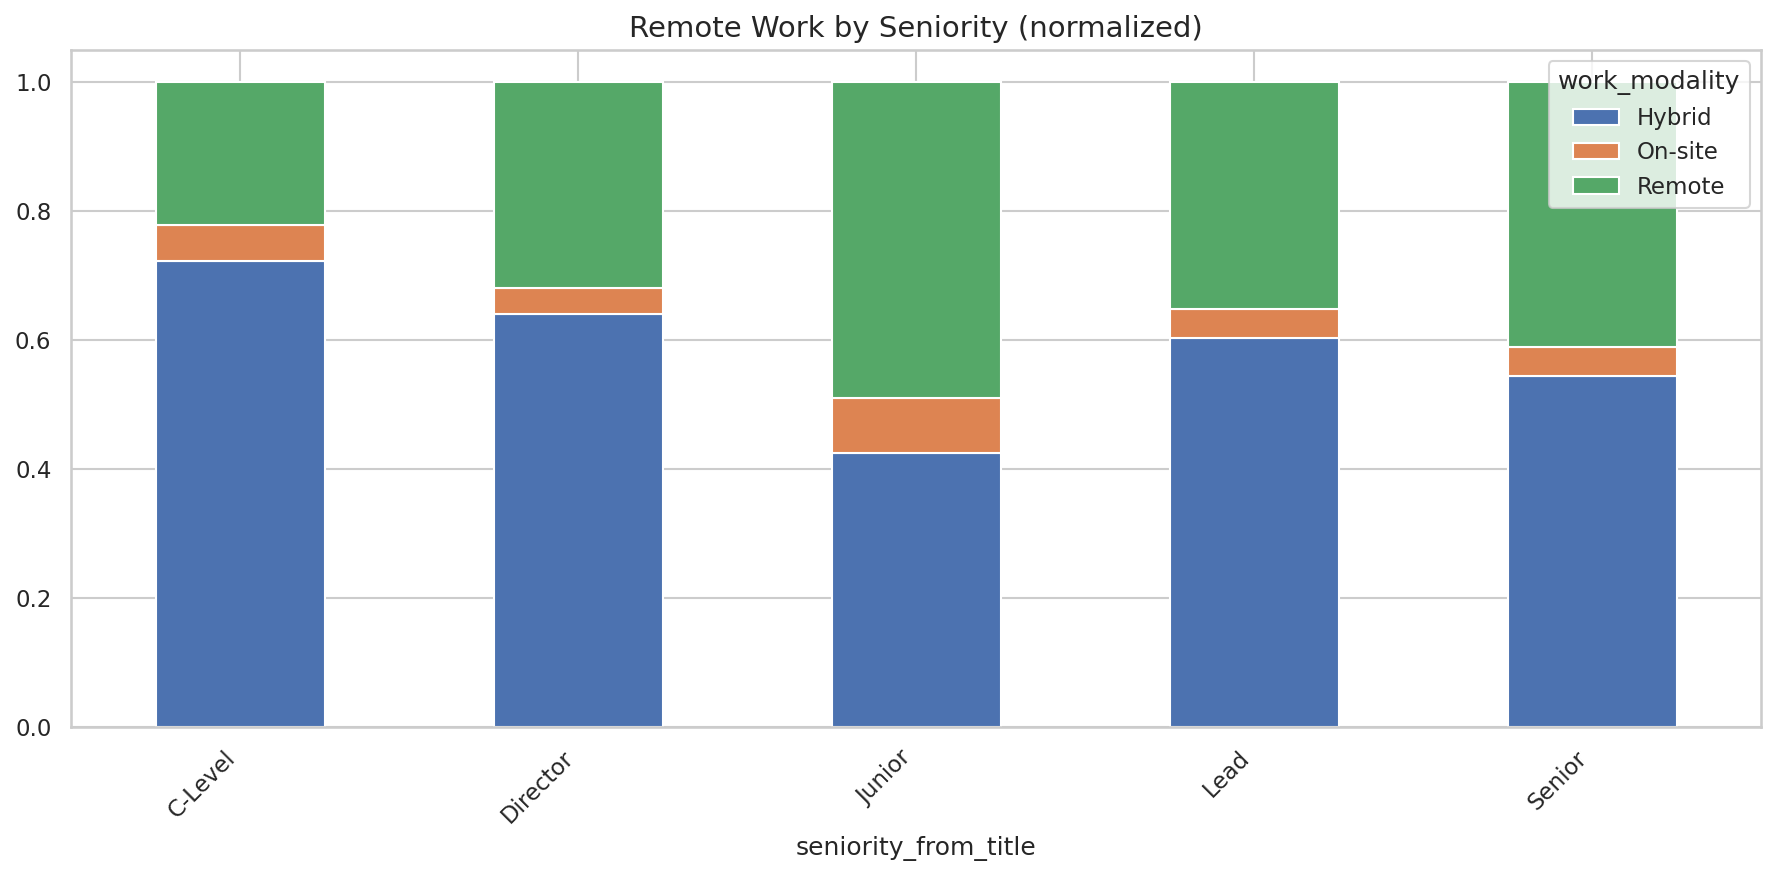

In [6]:
# Print sample sizes per seniority level
seniority_counts = df["seniority_from_title"].value_counts(dropna=False)
print("Sample sizes per seniority level:")
for level, n in seniority_counts.items():
    label = level if pd.notna(level) else "(unspecified)"
    print(f"  {label}: n={n:,}")
print()

ct_seniority = pd.crosstab(
    df["seniority_from_title"],
    df["work_modality"],
    normalize="index",
)
stacked_bar(ct_seniority, "Remote Work by Seniority (normalized)", save_as="05_remote_seniority.png")

**Takeaway:** Senior and Lead roles tend to enjoy slightly more remote flexibility than Junior positions. This makes sense: experienced hires have more negotiating leverage, and employers trust them to work independently. Entry-level roles more often require on-site presence, likely for mentoring and onboarding reasons.

## Language Requirements × Remote

German required:      6,960
No German specified:  12,138  (includes 0 with no language data at all)



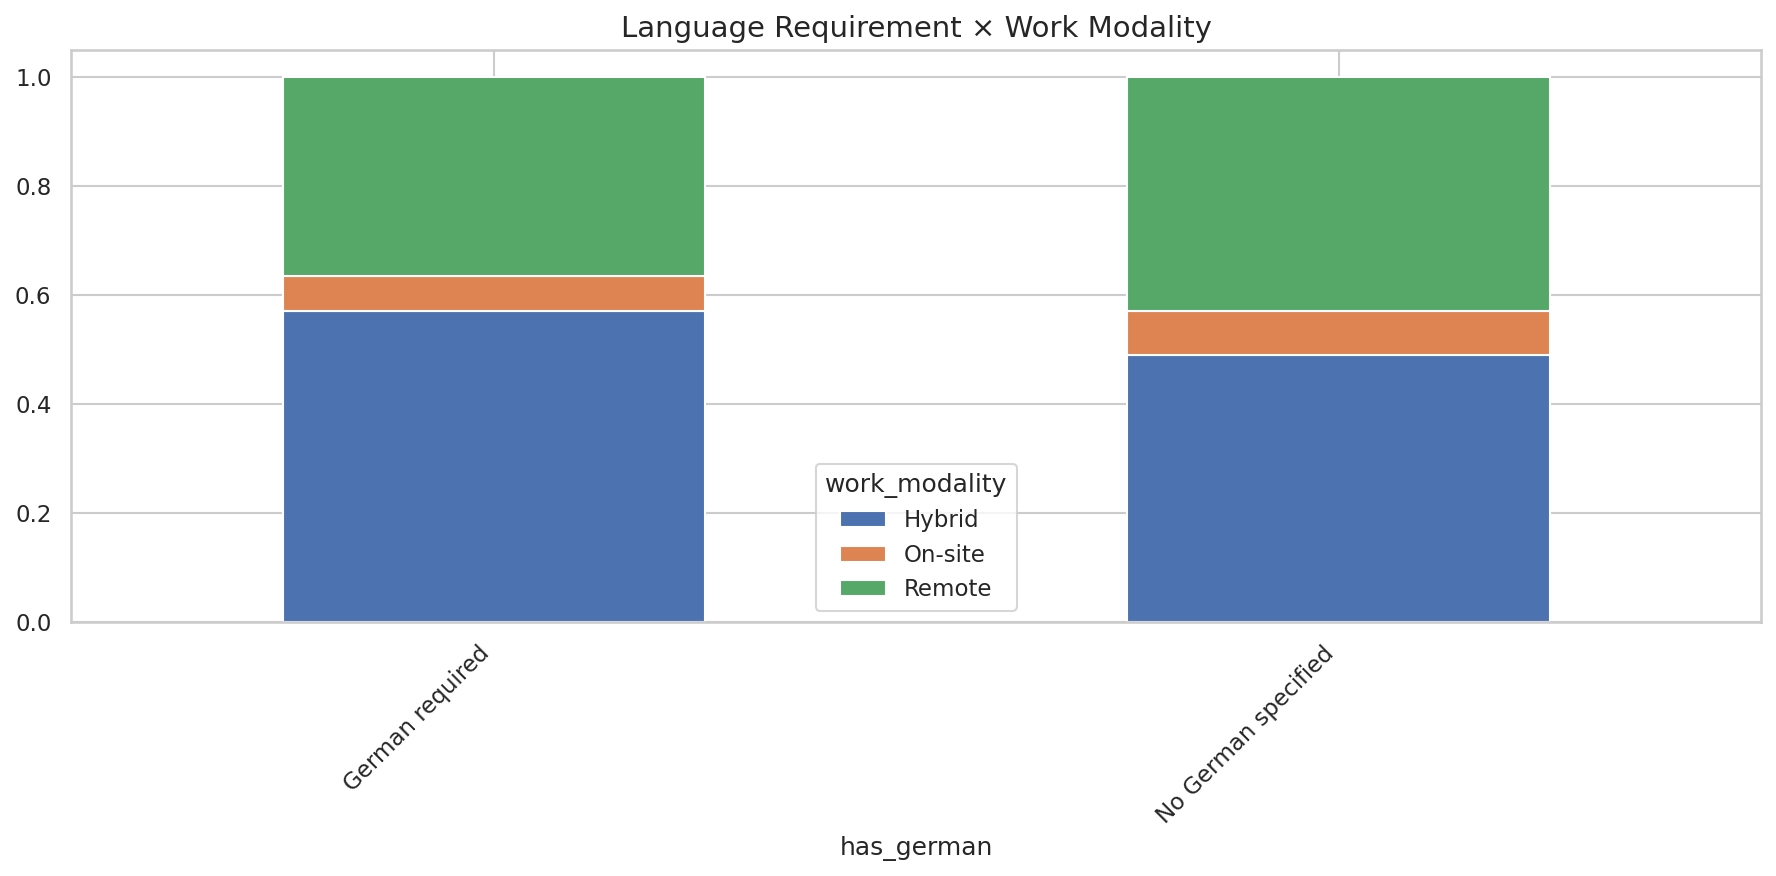

In [7]:
# Simplified German language detection (string-based, no JSON parsing needed)
df2 = df.copy()
df2["has_german"] = df2["languages"].apply(
    lambda x: "german" in str(x).lower() if pd.notna(x) else False
)

# Print breakdown
n_german = df2["has_german"].sum()
n_no_german = (~df2["has_german"]).sum()
n_lang_missing = df2["languages"].isna().sum()
print(f"German required:      {n_german:,}")
print(f"No German specified:  {n_no_german:,}  (includes {n_lang_missing:,} with no language data at all)")
print()

ct_lang = pd.crosstab(
    df2["has_german"].map({True: "German required", False: "No German specified"}),
    df2["work_modality"],
    normalize="index",
)
stacked_bar(ct_lang, "Language Requirement × Work Modality", save_as="05_lang_modality.png")

**Takeaway:** Postings that do not require German have a notably higher remote share. This is consistent with international/English-first teams that are more likely to support distributed work. Note that "No German specified" includes both English-only roles and postings with no language data at all, so this category is a mix of deliberately international roles and simply under-specified listings.